In [2]:
from agnpy.emission_regions import Cone
import astropy.units as u
from agnpy.spectra import ParticleDistribution
from agnpy.utils.conversion import nu_to_epsilon_prime, B_to_cgs, lambda_c_e, mec2
from agnpy.spectra.spectra import ExpCutoffPowerLaw
from agnpy.synchrotron import *
from scipy.interpolate import interp1d
from scipy.integrate import cumulative_trapezoid
from agnpy.synchrotron.base_synchrotron import Synchrotron
import numpy as np
from astropy.constants import c, sigma_T, m_e, e, mu0
#e = e.gauss
mec2 = mec2.to('eV')
import matplotlib.pyplot as plt

*Parameters used in Potter and Cotter to fit the BL Lac (Table 1)*

In [ ]:
# Parameters used in Table 1 of Potter and Cotter; Fitting BL Lac (abdo et al. 2011)
z=0.0686
B_o =  (3.63 * 1e-5 * u.T).to(u.G)
u_B = ((B_to_cgs(B_o)**2)/(8*np.pi)).to('erg cm-3')
R_o = 7.32 * 1e15 * u.cm
W_j = 7.63 * 1e36* u.W
L = (100 * u.pc)
theta_open = 9.7 * u.deg
Gamma = 12
theta_s = 2 * u.deg
A_equi = 1.0
# Electron Distribution imposed by Potter and Cotter
p = 2
gamma_minimum = (5.11 * 1e6 * u.eV / mec2.to("eV")).value
gamma_c = (5.6 * 1e9 * u.eV / mec2.to("eV")).value
n_e = ExpCutoffPowerLaw(k = 1 , mass=m_e, p=p, gamma_min = 0.1*gamma_minimum, gamma_max= 100*gamma_c, gamma_c= gamma_c )


In [4]:
jet = Cone.from_jet_power(W_j = W_j , B_o = B_o , L = L, n_e = n_e, theta = theta_open, Gamma=Gamma,x_size=100,gamma_e_size=1000, z =z,delta_D=20.39)

In [5]:
jet.delta_D

20.39

# Plots 

In [5]:
#Electron distribution
coordinates = [
    (585945.3915069195, 6.65905647933771e+45),
    (1180320.6356517298, 3.6753441641809446e+45),
    (2421029.04673618, 1.8950291465743076e+45),
    (5861381.645140285, 8.435148160601475e+44),
    (14454397.70745931, 3.481142923888426e+44),
    (23768402.866248783, 2.075324880373661e+44),
    (46989410.860521704, 1.1534180805525196e+44),
    (147231250.24327165, 3.8169973137017866e+43),
    (325087297.38543606, 1.693846972334023e+43),
    (831763771.1026742, 6.485157528062233e+42),
    (1614358556.8264935, 2.865619626947542e+42),
    (3076096814.7407174, 1.1725707943387419e+42),
    (5445026528.424242, 4.4349366153056454e+41),
    (10964781961.43192, 7.858944800779638e+40),
    (18030177408.59577, 1.2817831835790027e+40),
    (28575905433.749672, 1.2244668158998756e+39),
    (39084089579.24041, 1.164019524379192e+38),
    (59703528658.38415, 2.0753248803736612e+36),
    (89536476554.96011, 4.373153302721358e+33),
    (109647819614.31963, 7.740013565615246e+31),
    (129419584144.9997, 1.4766294411828247e+30)
]
x_data, y_data = zip(*coordinates)

# Data for the SED model of Synchrotron no-losses in Potter and Cotter in Figure 3 
x = [
    0.0003131660307862803, 0.0008840541623107365, 0.0029160081428143986, 0.001735547961136756,
    0.0014102489162420165, 0.0010879770097760172, 0.00781551761898938, 0.019888020057617743,
    0.048049640295616425, 0.1758208691205636, 0.6433550350871309, 1.7243273563482122,
    8.614126945081937, 16.05586850963554, 45.3250224803085, 109.50567327768607,
    238.4870429629985, 422.0385406871394, 639.1956383150009, 968.0894625777796,
    1392.0728770831072, 0.0000014950230456510178, 0.0000030912978018310354, 0.000007866375035417703,
    0.000027328746886507512, 0.00005093804274539881, 0.0001168437895408067
]

# Power / Flux data
y = [
    2.040490199884694e-12, 5.3169639633078265e-12, 1.503111337089843e-11, 1.08492128602697e-11,
    8.495785518249259e-12, 6.6528671251731555e-12, 2.1691180377984993e-11, 2.8852070927376698e-11,
    3.4659557108295606e-11, 4.249311650934016e-11, 4.705073061902792e-11, 4.6101686610606826e-11,
    3.396045117358661e-11, 2.7141154583473827e-11, 1.472792598364928e-11, 6.929596780336585e-12,
    2.169118037798499e-12, 6.652867125173156e-13, 1.842836161290166e-13, 4.163600255825478e-14,
    1.0000000000000041e-14, 1.0000000000000041e-14, 2.125365508342596e-14, 5.316963963307826e-14,
    1.769243507691091e-13, 3.327544666280575e-13, 7.672833112592147e-13
]
# Optional: sort the data by frequency for a smoother curve
sorted_data = sorted(zip(x, y))
x_sorted, y_sorted = zip(*sorted_data)

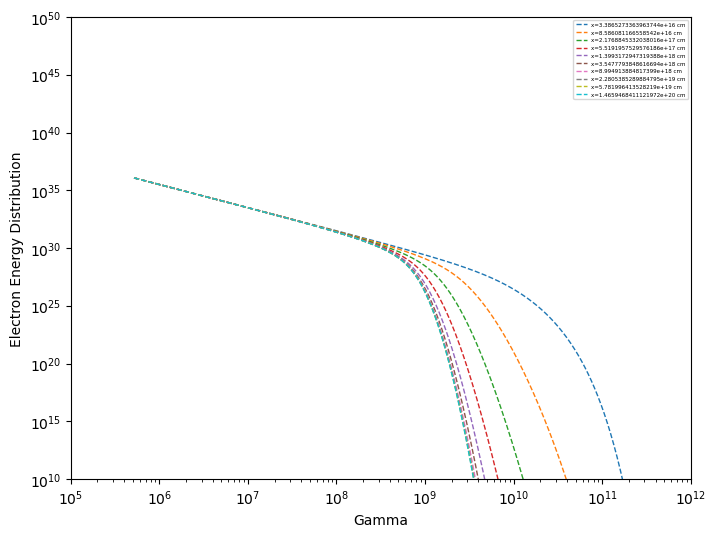

In [6]:
plt.figure(figsize=(8,6))
for i, _n_e_g in enumerate(jet.N_e_xg[::10]):
    plt.loglog(mec2.to('eV')*jet.gamma_e, _n_e_g, label=f"x={jet.x[10*i]}",linestyle='dashed',lw=1)
plt.xlabel('Gamma')
plt.ylabel('Electron Energy Distribution')
plt.legend(fontsize=4)
plt.ylim(1e10,1e50)
plt.xlim(1e5,1e12)
plt.show()

In [7]:
for i, N_e_x in enumerate(jet.N_e_xg[::5]):
    print(np.trapz(N_e_x,jet.gamma_e))

1.2191354483393881e+36 1 / cm
1.217758910453373e+36 1 / cm
1.2161959927748132e+36 1 / cm
1.214544860210156e+36 1 / cm
1.212951384404953e+36 1 / cm
1.211551683027988e+36 1 / cm
1.2104243879757455e+36 1 / cm
1.209579948016784e+36 1 / cm
1.2089817216985136e+36 1 / cm
1.2085746804394774e+36 1 / cm
1.2083053331763008e+36 1 / cm
1.208130388762732e+36 1 / cm
1.2080181352293407e+36 1 / cm
1.2079466704037345e+36 1 / cm
1.2079014005462835e+36 1 / cm
1.2078728150763112e+36 1 / cm
1.2078548011329757e+36 1 / cm
1.2078434635139157e+36 1 / cm
1.2078363335329699e+36 1 / cm
1.2078318518939638e+36 1 / cm


In [8]:
nu_obs = np.logspace(3, 25, 1000) * u.Hz
syn= Synchrotron(jet)
flux = syn.flux_obs(nu_obs)

In [9]:
syn.evaluate_attenuation()

/opt/anaconda3/lib/python3.12/site-packages/astropy/units/quantity.py:671: RuntimeWarning: divide by zero encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/opt/anaconda3/lib/python3.12/site-packages/astropy/units/quantity.py:671: RuntimeWarning: invalid value encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/opt/anaconda3/lib/python3.12/site-packages/astropy/units/quantity.py:671: RuntimeWarning: overflow encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


<Quantity [2.70799177e-19, 2.94695844e-19, 3.20701882e-19, 3.49003564e-19,
           3.79803622e-19, 4.13322702e-19, 4.49800950e-19, 4.89499735e-19,
           5.32703529e-19, 5.79721949e-19, 6.30891982e-19, 6.86580407e-19,
           7.47186435e-19, 8.13144572e-19, 8.84927755e-19, 9.63050744e-19,
           1.04807383e-18, 1.14060688e-18, 1.24131369e-18, 1.35091681e-18,
           1.47020274e-18, 1.60002755e-18, 1.74132311e-18, 1.89510379e-18,
           2.06247375e-18, 2.24463493e-18, 2.44289573e-18, 2.65868042e-18,
           2.89353946e-18, 3.14916070e-18, 3.42738155e-18, 3.73020227e-18,
           4.05980048e-18, 4.41854686e-18, 4.80902233e-18, 5.23403676e-18,
           5.69664932e-18, 6.20019064e-18, 6.74828698e-18, 7.34488656e-18,
           7.99428819e-18, 8.70117255e-18, 9.47063615e-18, 1.03082285e-17,
           1.12199923e-17, 1.22125077e-17, 1.32929401e-17, 1.44690925e-17,
           1.57494622e-17, 1.71433033e-17, 1.86606939e-17, 2.03126099e-17,
           2.21110058e-17

In [10]:
sed_nossa= syn.sed_flux(nu_obs, ssa=False)
sed_ssa= syn.sed_flux(nu_obs, ssa=True)

In [11]:
sed_x_nossa = syn.sed_spatial(nu_obs) 
sed_x_ssa = syn.sed_spatial(nu_obs,ssa=True)

/Users/usharma/Documents/GitHub/agnpy/agnpy/synchrotron/synchrotron_cone.py:36: RuntimeWarning: divide by zero encountered in divide
  u = 0.5 + np.exp(-tau) / tau - (1 - np.exp(-tau)) / np.power(tau, 2)
/Users/usharma/Documents/GitHub/agnpy/agnpy/synchrotron/synchrotron_cone.py:36: RuntimeWarning: overflow encountered in divide
  u = 0.5 + np.exp(-tau) / tau - (1 - np.exp(-tau)) / np.power(tau, 2)
/Users/usharma/Documents/GitHub/agnpy/agnpy/synchrotron/synchrotron_cone.py:36: RuntimeWarning: invalid value encountered in divide
  u = 0.5 + np.exp(-tau) / tau - (1 - np.exp(-tau)) / np.power(tau, 2)
/Users/usharma/Documents/GitHub/agnpy/agnpy/synchrotron/synchrotron_cone.py:37: RuntimeWarning: overflow encountered in divide
  return np.where(tau < 1e-3, 1, 3 * u / tau)


# SED

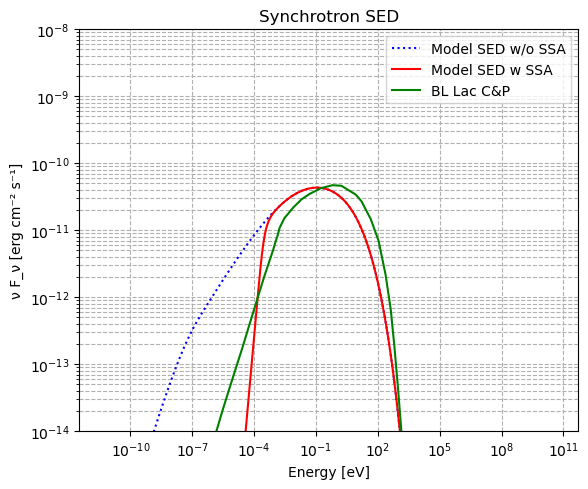

In [12]:
# Plot SED
plt.figure(figsize=(6,5))
plt.loglog((nu_obs).to(u.eV, equivalencies=u.spectral()), sed_nossa, color='blue', linestyle='dotted', label='Model SED w/o SSA')
plt.loglog((nu_obs).to(u.eV, equivalencies=u.spectral()), sed_ssa, color='red', linestyle='solid', label='Model SED w SSA')
#plt.loglog((nu_obs).to(u.eV, equivalencies=u.spectral()), sed_blob, color='black', linestyle='dotted', label='Model SED w Blob')
# Overlay updated data points
plt.loglog(x_sorted, y_sorted, linestyle='solid', color='green',label='BL Lac C&P')

plt.xlabel("Energy [eV]")
plt.ylabel("ν F_ν [erg cm⁻² s⁻¹]")
plt.title("Synchrotron SED")
plt.grid(True, which='both', ls='--')
plt.ylim(1e-14, 1e-8)
#plt.xlim(1e-8,1e6)
plt.legend()
plt.tight_layout()
plt.show()

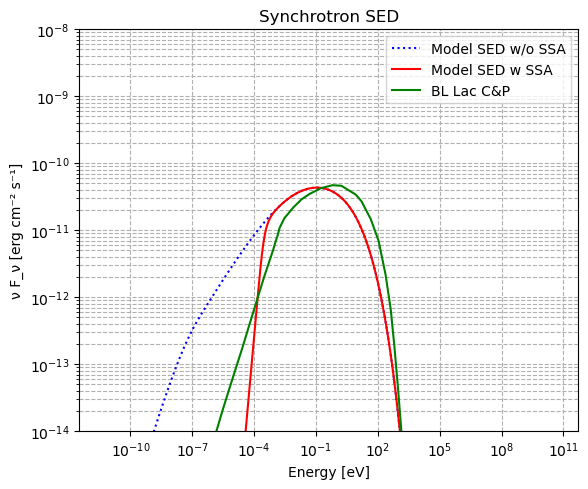

In [13]:
# Plot SED
plt.figure(figsize=(6,5))
plt.loglog((nu_obs).to(u.eV, equivalencies=u.spectral()), sed_nossa, color='blue', linestyle='dotted', label='Model SED w/o SSA')
plt.loglog((nu_obs).to(u.eV, equivalencies=u.spectral()), sed_ssa, color='red', linestyle='solid', label='Model SED w SSA')
#plt.loglog((nu_obs).to(u.eV, equivalencies=u.spectral()), sed_blob, color='black', linestyle='dotted', label='Model SED w Blob')
# Overlay updated data points
plt.loglog(x_sorted, y_sorted, linestyle='solid', color='green',label='BL Lac C&P')

plt.xlabel("Energy [eV]")
plt.ylabel("ν F_ν [erg cm⁻² s⁻¹]")
plt.title("Synchrotron SED")
plt.grid(True, which='both', ls='--')
plt.ylim(1e-14, 1e-8)
#plt.xlim(1e-8,1e6)
plt.legend()
plt.tight_layout()
plt.show()

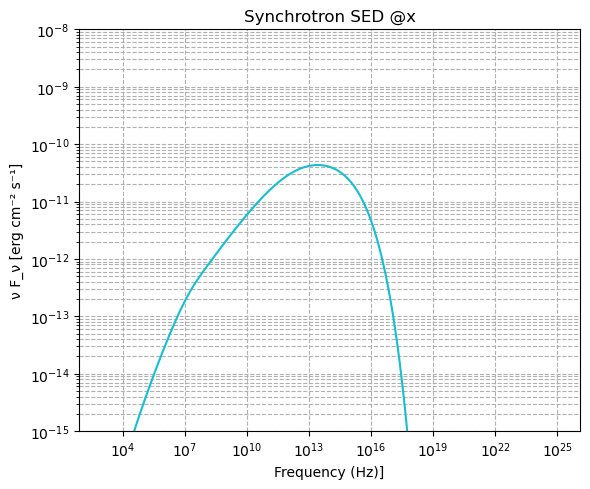

In [14]:
# Plot SED
plt.figure(figsize=(6,5))
for i, sed in enumerate(sed_x_nossa[::1]):
    plt.loglog(nu_obs, sed, linestyle='dotted',lw=0.8,label = jet.x[i])
plt.loglog(nu_obs,np.trapz(sed_x_nossa,jet.x,axis=0))
plt.xlabel("Frequency (Hz)]")
plt.ylabel("ν F_ν [erg cm⁻² s⁻¹]")
plt.title("Synchrotron SED @x")
plt.grid(True, which='both', ls='--')
plt.ylim(1e-15, 1e-8)
#plt.xlim(1,1e20)
#plt.legend()
plt.tight_layout()
plt.show()

'\nfor i, sed in enumerate(sed_x_ssa[::50]):\n    axes[1].loglog(nu_obs, sed, linestyle=\'dashed\', lw=0.5,label = jet.x[50*i])\n#axes[1].loglog((nu_obs), np.trapz(sed_x_ssa,jet.x,axis = 0), linestyle=\'solid\', color=\'red\',label=\'Model SED w SSA\')\naxes[1].set_title("Synchrotron SED (With SSA)")\naxes[1].loglog(nu_obs, np.trapz(sed_x_ssa,jet.x,axis=0),color=\'blue\')\naxes[1].set_xlabel("Frequency (Hz)")\naxes[1].set_ylabel(r"$\nu F_\nu$ [erg cm$^{-2}$ s$^{-1}$]")\naxes[1].grid(True, which=\'both\', ls=\'--\')\naxes[1].set_ylim(1e-14, 1e-9)\naxes[1].set_xlim(1e2,1e22)\naxes[1].legend(fontsize=5)\nplt.tight_layout()\nplt.show()\n'

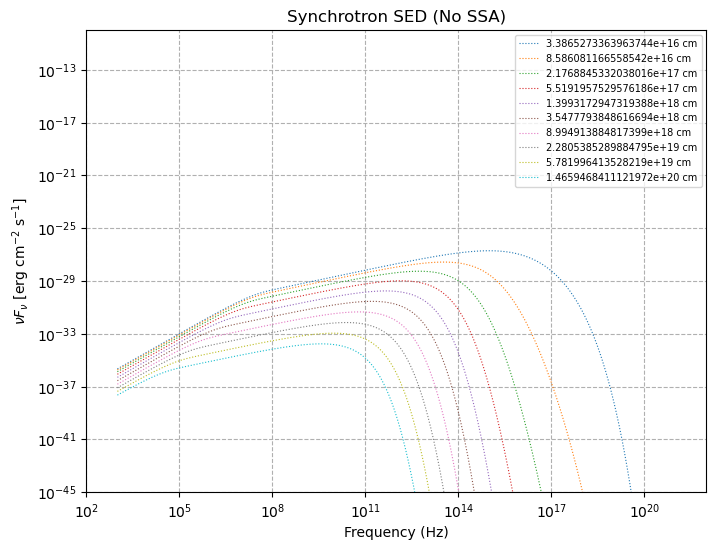

In [15]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1,1, figsize=(8, 6), sharex=True)

# -------------------------
# Top: without SSA
# -------------------------
for i, sed in enumerate(sed_x_nossa[::10]):
    axes.loglog(nu_obs, sed, linestyle='dotted',lw=0.8,label = jet.x[10*i])
#axes.loglog(nu_obs, np.trapz(sed_x_nossa,jet.x,axis = 0), linestyle='solid', color='red',label='Model SED w/o SSA')
#axes.loglog(x_sorted, y_sorted, linestyle='solid', color='green',label='BL Lac C&P')
axes.set_title("Synchrotron SED (No SSA)")
axes.set_ylabel(r"$\nu F_\nu$ [erg cm$^{-2}$ s$^{-1}$]")
axes.set_xlabel("Frequency (Hz)")
axes.grid(True, which='both', ls='--')
axes.set_ylim(1e-45, 1e-10)
axes.set_xlim(1e2,1e22)
axes.legend(fontsize=7)
""""""
# -------------------------
# Bottom: with SSA
# -------------------------
"""
for i, sed in enumerate(sed_x_ssa[::50]):
    axes[1].loglog(nu_obs, sed, linestyle='dashed', lw=0.5,label = jet.x[50*i])
#axes[1].loglog((nu_obs), np.trapz(sed_x_ssa,jet.x,axis = 0), linestyle='solid', color='red',label='Model SED w SSA')
axes[1].set_title("Synchrotron SED (With SSA)")
axes[1].loglog(nu_obs, np.trapz(sed_x_ssa,jet.x,axis=0),color='blue')
axes[1].set_xlabel("Frequency (Hz)")
axes[1].set_ylabel(r"$\nu F_\nu$ [erg cm$^{-2}$ s$^{-1}$]")
axes[1].grid(True, which='both', ls='--')
axes[1].set_ylim(1e-14, 1e-9)
axes[1].set_xlim(1e2,1e22)
axes[1].legend(fontsize=5)
plt.tight_layout()
plt.show()
"""


In [16]:
nu_peak = syn.nu_peak()
nu_fluid = nu_obs*(1+jet.z)/jet.delta_D

In [17]:
print(nu_peak.shape)

(99, 499, 1)


In [18]:
nu_peak[0,1,:]

<Quantity [1325673.89027814] Hz>

In [19]:
(nu_fluid/nu_peak[0,0,:])

<Quantity [4.17801151e-05, 4.39533169e-05, 4.62395582e-05, 4.86447189e-05,
           5.11749845e-05, 5.38368625e-05, 5.66371986e-05, 5.95831948e-05,
           6.26824276e-05, 6.59428678e-05, 6.93729004e-05, 7.29813469e-05,
           7.67774875e-05, 8.07710853e-05, 8.49724108e-05, 8.93922693e-05,
           9.40420276e-05, 9.89336441e-05, 1.04079699e-04, 1.09493427e-04,
           1.15188752e-04, 1.21180320e-04, 1.27483541e-04, 1.34114625e-04,
           1.41090626e-04, 1.48429486e-04, 1.56150078e-04, 1.64272258e-04,
           1.72816915e-04, 1.81806025e-04, 1.91262705e-04, 2.01211276e-04,
           2.11677324e-04, 2.22687766e-04, 2.34270919e-04, 2.46456572e-04,
           2.59276064e-04, 2.72762365e-04, 2.86950158e-04, 3.01875933e-04,
           3.17578076e-04, 3.34096968e-04, 3.51475095e-04, 3.69757148e-04,
           3.88990147e-04, 4.09223554e-04, 4.30509406e-04, 4.52902447e-04,
           4.76460266e-04, 5.01243451e-04, 5.27315738e-04, 5.54744181e-04,
           5.83599320e-04

In [20]:
F_xv = syn.Flux_xv()

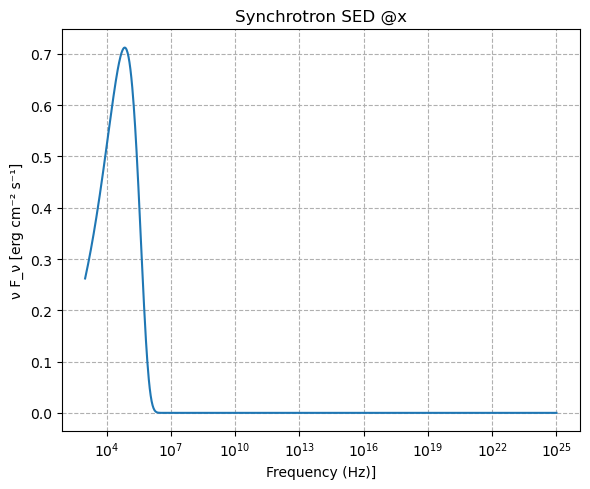

In [21]:
# Plot SED
plt.figure(figsize=(6,5))
plt.plot(nu_obs,syn.Bessel()[70,10,:])
plt.xlabel("Frequency (Hz)]")
plt.ylabel("ν F_ν [erg cm⁻² s⁻¹]")
plt.title("Synchrotron SED @x")
plt.grid(True, which='both', ls='--')
#plt.ylim(1e-10, 1e10)
#plt.xlim(1,1e20)
#plt.legend()
plt.xscale('log')
plt.tight_layout()
plt.show()

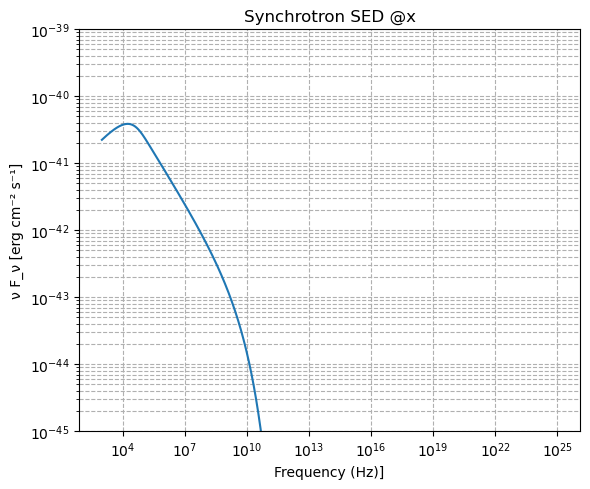

In [22]:
# Plot SED
plt.figure(figsize=(6,5))
plt.loglog(nu_obs,F_xv[90,:])
plt.xlabel("Frequency (Hz)]")
plt.ylabel("ν F_ν [erg cm⁻² s⁻¹]")
plt.title("Synchrotron SED @x")
plt.grid(True, which='both', ls='--')
plt.xscale('log')
plt.ylim(1e-45, 1e-39)
#plt.xlim(1,1e20)
#plt.legend()
plt.tight_layout()
plt.show()